### `Heart Disease Prediction`

Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5 CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

#### `Importing libraries`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import plotly.express as px
import plotly.graph_objects as go


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')



`Reading the Dataset`

In [39]:
heart_disease = pd.read_csv('../Dataset/heart.csv')

heart_disease.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [40]:
heart_disease.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


`Exploring the Dataset`

In [41]:
print(heart_disease.info())
heart_disease.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


`Shape of the data`

In [42]:
heart_disease.shape

(918, 12)

`Checking for missing values`

In [43]:
heart_disease.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

`Checking for Duplicated values`

In [44]:
heart_disease.duplicated().sum()

np.int64(0)

`Handling Outliers`

In [45]:
q1 = heart_disease.select_dtypes(include='number').quantile(0.25)
q3 = heart_disease.select_dtypes(include='number').quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print('Lower Bound:\n', lower_bound)
print('Upper Bound:\n', upper_bound)

Lower Bound:
 Age             27.500
RestingBP       90.000
Cholesterol     32.625
FastingBS        0.000
MaxHR           66.000
Oldpeak         -2.250
HeartDisease    -1.500
dtype: float64
Upper Bound:
 Age              79.500
RestingBP       170.000
Cholesterol     407.625
FastingBS         0.000
MaxHR           210.000
Oldpeak           3.750
HeartDisease      2.500
dtype: float64


In [46]:
for cols in heart_disease.select_dtypes(include='number').columns:
    mask = (heart_disease[cols] < lower_bound[cols]) | (heart_disease[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols} : {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].max():.2f}')

RestingBP : 28 outliers | bounds=[90.00, 170.00] | actual_min=90.00, actual_max=170.00
Cholesterol : 183 outliers | bounds=[32.62, 407.62] | actual_min=32.62, actual_max=407.62
FastingBS : 214 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00
MaxHR : 2 outliers | bounds=[66.00, 210.00] | actual_min=66.00, actual_max=210.00
Oldpeak : 16 outliers | bounds=[-2.25, 3.75] | actual_min=-2.25, actual_max=3.75


`Visualizing the Outliers`

In [47]:
figure = px.box(heart_disease.select_dtypes(include='number'), orientation='h')

figure.show()

`Fixing Missing or Zero Outlier Analysis`

In [48]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

heart_disease['Cholesterol'] = heart_disease['Cholesterol'].replace(0, np.nan)

imputer = IterativeImputer(random_state=42)
heart_disease[['Cholesterol']] = imputer.fit_transform(heart_disease[['Cholesterol']])

In [49]:
heart_disease['RestingBP'] = heart_disease['RestingBP'].replace(0, np.nan)

imputer = IterativeImputer(random_state=42)
heart_disease[['RestingBP']] = imputer.fit_transform(heart_disease[['RestingBP']])

In [50]:
heart_disease.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


`Data Visualization`

In [51]:
sex = heart_disease['Sex'].value_counts().reset_index()

sex

,Sex,count
0,M,725
1,F,193


In [52]:
figure = px.bar(
    sex,
    x = sex['Sex'],
    y = sex['count'],
    color = sex['Sex'],
    title = 'Gender Distribution'
)

figure.show()

In [53]:
ChestPainType = heart_disease['ChestPainType'].value_counts().reset_index()

ChestPainType

,ChestPainType,count
0,ASY,496
1,NAP,203
2,ATA,173
3,TA,46


In [54]:
figure = px.bar(
    ChestPainType,
    x = ChestPainType['ChestPainType'],
    y = ChestPainType['count'],
    color = ChestPainType['ChestPainType'],
    title = 'Chest Pain Type Distribution'
)

figure.show()

In [55]:
RestingECG = heart_disease['RestingECG'].value_counts().reset_index()

RestingECG

,RestingECG,count
0,Normal,552
1,LVH,188
2,ST,178


In [56]:
figure = px.bar(
    RestingECG,
    x = RestingECG['RestingECG'],
    y = RestingECG['count'],
    color = RestingECG['RestingECG'],
    title = 'RestingECG Distribution'
)

figure.show()

In [57]:
ST_Slope = heart_disease['ST_Slope'].value_counts().reset_index()

ST_Slope

,ST_Slope,count
0,Flat,460
1,Up,395
2,Down,63


In [58]:
figure = px.bar(
    ST_Slope,
    x = ST_Slope['ST_Slope'],
    y = ST_Slope['count'],
    color = ST_Slope['ST_Slope'],
    title = 'ST Slope Distribution'
)

figure.show()

In [59]:
HeartDisease = heart_disease['HeartDisease'].value_counts().reset_index()

HeartDisease

,HeartDisease,count
0,1,508
1,0,410


In [60]:
HeartDisease = heart_disease['HeartDisease'].value_counts()
labels = HeartDisease.index
values = HeartDisease.values
colors = ['blue', 'green']

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.5)])
fig.update_layout(title_text='Heart Disease Distribution')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

`Correlation Matrix`

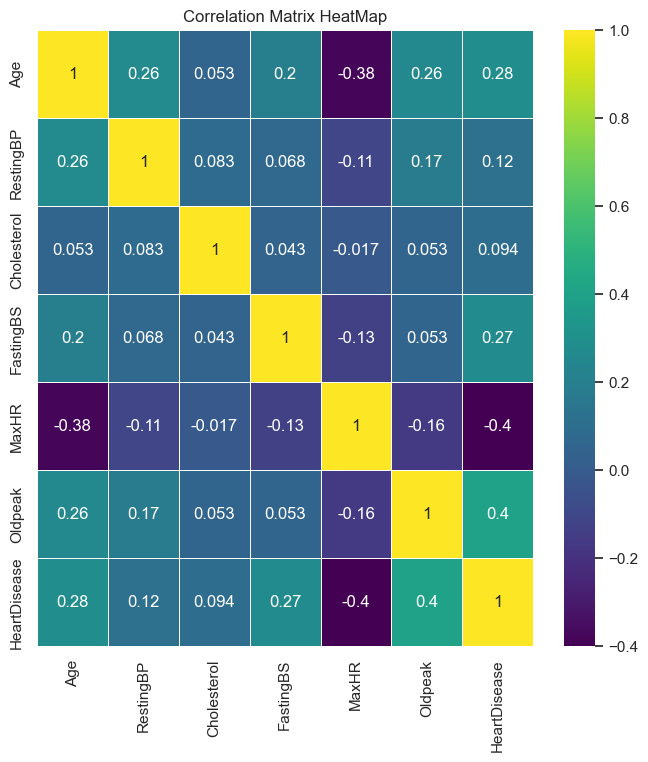

In [61]:
corr_matrix = heart_disease.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Matrix HeatMap')
plt.show()

`Feature Selection and Data Splitting`

In [62]:
X = heart_disease.drop(columns='HeartDisease', axis=1)
y = heart_disease['HeartDisease']

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

`Encoding Categorical Features Using OneHotEncoder`

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_col=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_col=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
    ]
)

### `Model Training, Evaluation and Cross Validation`

#### `Logistic Regression`

In [64]:
lr_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('lr', LogisticRegression(class_weight='balanced'))
])

lr_pipe.fit(X_train, y_train)

y_pred = lr_pipe.predict(X_test)
print(y_pred)

lr_y_prob = lr_pipe.predict_proba(X_test)[:, 1]

[0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1
 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1
 0 1 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 1
 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 1 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1]


`Train and Test Score`

In [65]:
train_score = lr_pipe.score(X_train, y_train)
test_score = lr_pipe.score(X_test, y_test)

print(f"Training Accuracy: {train_score:.2f}")
print(f"Testing Accuracy: {test_score:.2f}")

Training Accuracy: 0.86
Testing Accuracy: 0.83


`Model Accuracy`

In [66]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.83


`Prediction Probabilities`

In [67]:
lr_prediction_probabilities = print(lr_y_prob)
lr_prediction_probabilities

[0.01427292 0.59719084 0.89840859 0.94213886 0.06725632 0.81987444
 0.77306414 0.15091985 0.63419834 0.90555909 0.66196713 0.15343198
 0.74784666 0.07222826 0.87618708 0.27812788 0.03497633 0.58661697
 0.80619282 0.37555772 0.65123689 0.75292317 0.0565535  0.73092707
 0.94072214 0.9334584  0.0543623  0.62948879 0.03476334 0.02951339
 0.7555527  0.16271516 0.56506098 0.94814817 0.82547324 0.4038346
 0.95637242 0.05744955 0.95258439 0.73596322 0.9348982  0.82781133
 0.70574019 0.06334352 0.03516611 0.62758836 0.81009532 0.93464544
 0.81825703 0.3509858  0.04630645 0.03376578 0.83380389 0.96507564
 0.42385576 0.06374921 0.23766548 0.83289932 0.67181474 0.88882332
 0.07188807 0.10108962 0.00866238 0.94158082 0.02269006 0.93818501
 0.97391986 0.92436966 0.96859975 0.64205558 0.2167662  0.07894947
 0.47331917 0.53414036 0.25033611 0.93939931 0.3309739  0.47207682
 0.04873971 0.62853927 0.32939871 0.78674436 0.85102931 0.04808524
 0.88594562 0.68638702 0.06523934 0.73758152 0.06849727 0.03022

`Classification Report`

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.81        77
           1       0.90      0.79      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184



`RocCurveDisplay`

In [69]:
ras = roc_auc_score(y_test, y_pred)
print(f'roc_auc_score: {ras:.2f}')

roc_auc_score: 0.84


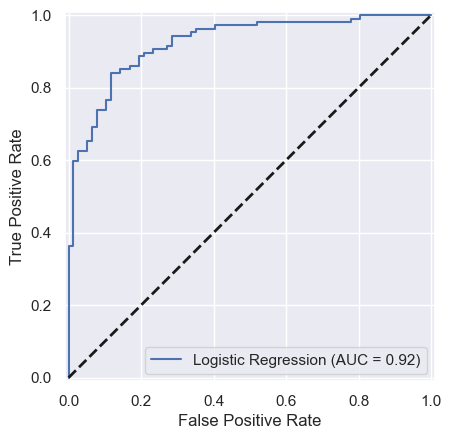

In [70]:

fpr, tpr, thresholds = metrics.roc_curve(y_test, lr_y_prob)
lr_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=lr_roc_auc, name='Logistic Regression')

display.plot()
plt.plot([0, 1], [0, 1], 'k--', label= 'Random Classifier', linewidth=2)
plt.show()

`Confusion Matrix`

In [71]:
print(confusion_matrix(y_test, y_pred))

[[68  9]
 [22 85]]


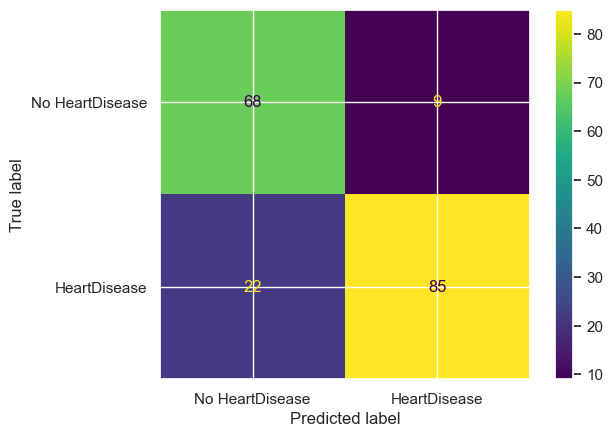

In [72]:
lr_confusion_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=lr_confusion_matrix, display_labels=['No HeartDisease', 'HeartDisease'])
disp.plot(cmap='viridis')
plt.show()

`Cross Validation`

In [73]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_score = cross_val_score(lr_pipe, X, y, cv=skf, scoring='roc_auc')
print(f'Cross Validation Accuracy Score: {cv_score}')
print(f'Mean Cross Validation Accuracy Score: {cv_score.mean():.3f} (+/- {cv_score.std() * 2:.3f})')

Cross Validation Accuracy Score: [0.93400287 0.91678623 0.89490674 0.9437334  0.8844482 ]
Mean Cross Validation Accuracy Score: 0.915 (+/- 0.045)


#### `RandomForestClassifier`

In [74]:
rfc_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('rfc', RandomForestClassifier(class_weight='balanced'))
])

rfc_pipe.fit(X_train, y_train)
y_pred = rfc_pipe.predict(X_test)
print(y_pred)

rfc_y_prob = rfc_pipe.predict_proba(X_test)[:, 1]

[0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1
 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 1
 0 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1
 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1]


`Model Accuracy`

In [75]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.86


In [76]:
rfc_predicition_probabilities = print(rfc_y_prob)
rfc_predicition_probabilities

[0.08 0.74 0.92 1.   0.07 0.75 0.91 0.18 0.7  1.   0.57 0.11 0.7  0.17
 0.86 0.58 0.06 0.61 0.68 0.3  0.73 0.83 0.02 0.52 0.57 1.   0.   0.56
 0.   0.03 0.88 0.1  0.51 0.92 0.92 0.43 0.99 0.01 0.91 0.81 0.87 0.85
 0.54 0.08 0.1  0.57 0.78 0.95 1.   0.61 0.1  0.03 0.89 0.98 0.67 0.16
 0.35 0.92 0.6  0.89 0.16 0.08 0.   0.91 0.05 0.98 0.96 0.91 1.   0.67
 0.52 0.02 0.42 0.56 0.06 0.6  0.2  0.7  0.16 0.78 0.55 0.93 0.87 0.02
 0.96 0.68 0.02 0.74 0.06 0.07 0.15 0.9  0.96 0.23 0.56 0.   0.96 0.2
 0.81 0.52 0.25 0.95 0.76 0.   0.85 0.89 0.1  0.15 0.96 0.42 0.91 0.84
 0.17 0.26 0.99 0.12 0.6  0.01 0.95 0.58 0.94 0.64 0.31 0.84 0.15 0.
 0.08 0.2  0.01 0.64 0.36 0.95 0.94 0.24 0.91 0.1  0.68 0.78 0.01 0.43
 0.18 0.17 0.81 0.77 0.85 0.83 0.87 0.14 0.17 0.35 0.01 0.68 0.91 0.07
 0.8  0.02 0.04 0.03 0.03 0.9  0.01 0.07 0.97 0.02 0.92 0.97 0.44 0.93
 0.17 0.37 0.96 0.92 0.1  0.89 0.01 0.92 0.14 0.75 0.1  0.67 0.73 0.99
 0.06 0.98]


`Classification Report`

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



`RocCurveDisplay`

In [78]:
ras = roc_auc_score(y_test, y_pred)
print(f'roc_auc_score: {ras:.2f}')

roc_auc_score: 0.86


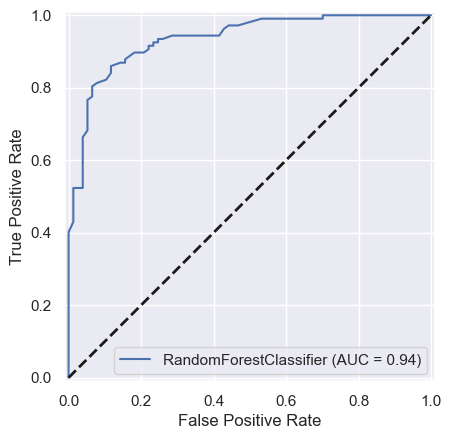

In [79]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, rfc_y_prob)
rfc_auc_score = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=rfc_auc_score, name='RandomForestClassifier')
display.plot()

plt.plot([0, 1], [0, 1], 'k--', label= 'Random Classifier', linewidth=2)
plt.show()

`Confusion Matrix`

In [80]:
print(confusion_matrix(y_test, y_pred))

[[65 12]
 [14 93]]


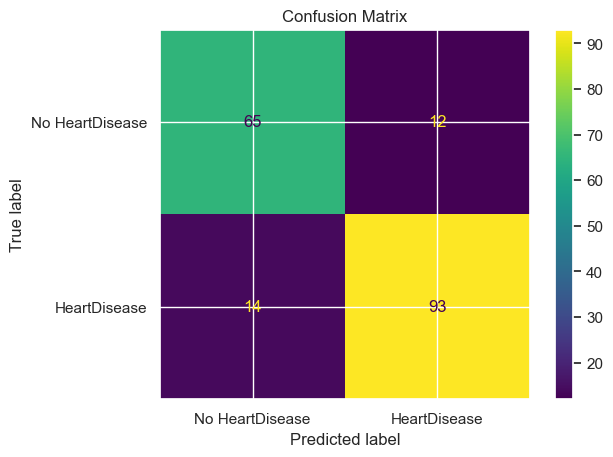

In [81]:
rfc_confusion_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=rfc_confusion_matrix, display_labels=['No HeartDisease', 'HeartDisease'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()

`Cross Validation`

In [82]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rfc_pipe, X, y, cv=skf, scoring='roc_auc')
print(f'Cross Validation Scores: {cv_scores}')
print(f'Mean Cross Validation Scores: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross Validation Scores: [0.94607843 0.93956241 0.8806791  0.94005071 0.88022217]
Mean Cross Validation Scores: 0.917 (+/- 0.060)


#### `XGBClassifier`

In [83]:
xgb_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('xgb', XGBClassifier())\
])

xgb_pipe.fit(X_train, y_train)

y_pred = xgb_pipe.predict(X_test)
print(y_pred)

xgb_y_prob = xgb_pipe.predict_proba(X_test)[:, 1]

[0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1
 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 1 1 0 0 0 1 0
 0 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1
 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 1 0
 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1]


`Model Accuracy`

In [84]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Acuracy: {accuracy:.2f}')

Model Acuracy: 0.85


`Prediction Probabilites`

In [85]:
xgb_prediction_probabilities = print(xgb_y_prob)
xgb_prediction_probabilities

[2.35278774e-02 9.68360424e-01 9.82551515e-01 9.99501109e-01
 1.21784974e-02 8.44297051e-01 9.98886645e-01 1.72346592e-01
 6.38764143e-01 9.93409276e-01 6.98705018e-01 1.29108075e-02
 8.04645061e-01 1.77234769e-01 9.97259974e-01 7.91453958e-01
 8.04090127e-03 9.05867815e-01 6.15908444e-01 4.36197929e-02
 9.92898822e-01 8.31049085e-01 1.11025001e-03 9.73326564e-02
 1.15662463e-01 9.90603268e-01 2.20669992e-03 9.57362771e-01
 3.09231546e-04 5.89884236e-04 9.98108625e-01 2.64022616e-03
 6.83397174e-01 9.91194487e-01 9.91424561e-01 8.24533284e-01
 9.99294758e-01 4.08998603e-04 9.23792660e-01 9.75853205e-01
 8.51726830e-01 9.75581288e-01 9.37588394e-01 1.48021558e-03
 3.52411298e-03 9.89299536e-01 9.53084886e-01 9.99703825e-01
 9.98387337e-01 8.25013936e-01 1.25535950e-02 6.86307496e-04
 9.92969096e-01 9.99693036e-01 6.93766356e-01 4.40479256e-03
 3.39799643e-01 9.93443012e-01 3.86115491e-01 9.81255710e-01
 2.81048659e-02 4.24382202e-02 4.35760885e-05 9.97993946e-01
 9.00637731e-03 9.998284

`Classification Report`

In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



`Roc Curve Display`

In [87]:
ras = roc_auc_score(y_test, y_pred)
print(f'roc auc score: {ras:.2f}')

roc auc score: 0.86


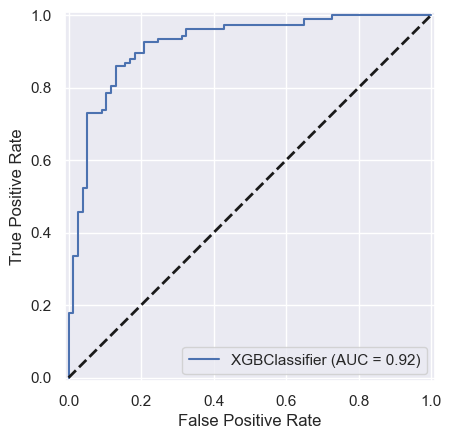

In [88]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, xgb_y_prob)
xgb_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=xgb_roc_auc, name='XGBClassifier')
display.plot()

plt.plot([0, 1], [0, 1], 'k--', label= 'Random Classifier', linewidth=2)
plt.show()

`Confusion Matrix`

In [89]:
print(confusion_matrix(y_test, y_pred))

[[67 10]
 [17 90]]


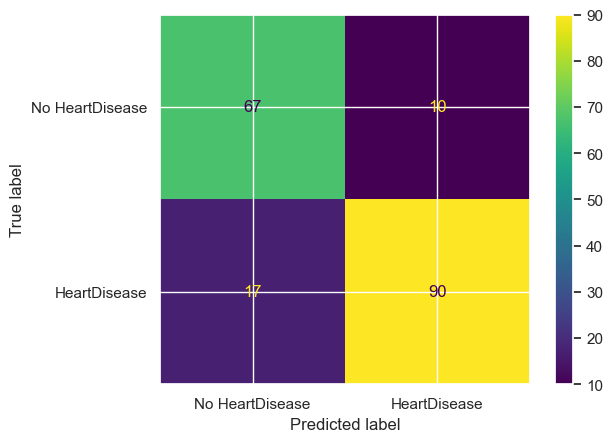

In [90]:
xgb_confusion_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix, display_labels=['No HeartDisease', 'HeartDisease'])
disp.plot(cmap='viridis')
plt.show()

`Cross Validation`

In [91]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_scores = cross_val_score(xgb_pipe, X, y, cv=skf, scoring='roc_auc')

print(f'Cross Validation Accuracy Scores: {xgb_cv_scores}')
print(f'Mean Cross Validation Accuracy: {xgb_cv_scores.mean():.3f} (+/- {xgb_cv_scores.std() * 2:.3f})')

Cross Validation Accuracy Scores: [0.93675275 0.91941655 0.87876614 0.93081381 0.90630283]
Mean Cross Validation Accuracy: 0.914 (+/- 0.041)


`Test Prediction on New Data`

In [92]:
new_data = pd.DataFrame([{
    'Age': 40,
    'Sex': 'M',
    'ChestPainType': 'ATA',
    'RestingBP': 140.0,
    'Cholesterol': 289.0,
    'FastingBS': 0,
    'RestingECG': 'Normal',
    'MaxHR': 172,
    'ExerciseAngina': 'N',
    'Oldpeak': 0.0,
    'ST_Slope': 'Up'
}])

lr_prediction = lr_pipe.predict(new_data)
rfc_prediction = rfc_pipe.predict(new_data)
xgb_prediction = xgb_pipe.predict(new_data)


print(f'========== LOGISTIC REGRESSION PREDICTION ==========')
print(lr_prediction)

if lr_prediction[0] == 1:
    print("The patient is predicted to have heart disease.")
else:
    print("The patient is predicted to not have heart disease.")

probability = lr_pipe.predict_proba(new_data)
print(probability)



print(f'========== RANDOMFOREST CLASSIFIER PREDICTION ==========')
print(rfc_prediction)

if rfc_prediction[0] == 1:
    print("The patient is predicted to have heart disease.")
else:
    print("The patient is predicted to not have heart disease.")

probability = rfc_pipe.predict_proba(new_data)
print(probability)



print(f'========== XGBCLASSIFIER PREDICTION ==========')
print(xgb_prediction)

if xgb_prediction[0] == 1:
    print("The patient is predicted to have heart disease.")
else:
    print("The patient is predicted to not have heart disease.")

probability = xgb_pipe.predict_proba(new_data)
print(probability)



========== LOGISTIC REGRESSION PREDICTION ==========
[0]
The patient is predicted to not have heart disease.
[[0.95662141 0.04337859]]
========== RANDOMFOREST CLASSIFIER PREDICTION ==========
[0]
The patient is predicted to not have heart disease.
[[1. 0.]]
========== XGBCLASSIFIER PREDICTION ==========
[0]
The patient is predicted to not have heart disease.
[[9.9941581e-01 5.8416725e-04]]


In [93]:
models = {
    "Logistic Regression": lr_pipe,
    "Random Forest": rfc_pipe,
    "XGBoost": xgb_pipe
}

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"\n{name}")
    print("Train Accuracy:", train_score)
    print("Test Accuracy:", test_score)


Logistic Regression
Train Accuracy: 0.8596730245231607
Test Accuracy: 0.8315217391304348

Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.8586956521739131

XGBoost
Train Accuracy: 1.0
Test Accuracy: 0.8532608695652174


In [94]:
from sklearn.metrics import roc_auc_score

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"{name} ROC AUC:", roc_auc)

Logistic Regression ROC AUC: 0.9241412792814662
Random Forest ROC AUC: 0.9350042480883602
XGBoost ROC AUC: 0.9198931909212283


Logistic Regression should be selected for production because it demonstrated strong generalization with minimal overfitting, achieving closely matched training and testing accuracies. Despite slightly lower accuracy than Random Forest, it provided stable performance, high ROC AUC, faster prediction speed, lower computational cost, and better interpretability, making it a more reliable and trustworthy model for heart disease prediction in a production environment.


`Saving Logistic Regression Model`

In [95]:
import joblib

joblib.dump(lr_pipe, '../models/heart_disease_model.joblib')

print('Model Saved')

Model Saved
